In [1]:
from pathlib import Path
import pandas as pd

In [2]:
train_data = Path("../data/train.csv")
test_data = Path("../data/test.csv")

train = pd.read_csv(train_data, parse_dates=["ds"])
test = pd.read_csv(test_data, parse_dates= ["ds"])

train.head()

,ds,y,unique_id
0,2022-01-01,0,1
1,2022-02-01,0,1
2,2022-03-01,3,1
3,2022-04-01,2,1
4,2022-05-01,20,1


In [3]:
import matplotlib.pyplot as plt
plt.style.use('grayscale')
plt.rcParams['lines.linewidth'] = 1.5
dark_style = {
    'figure.facecolor': '#008080',  # #212946
    'axes.facecolor': '#008080',
    'savefig.facecolor': '#008080',
    'axes.grid': True,
    'axes.grid.which': 'both',
    'axes.spines.left': False,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.spines.bottom': False,
    'grid.color': '#000000',  #2A3459
    'grid.linewidth': '1',
    'text.color': '0.9',
    'axes.labelcolor': '0.9',
    'xtick.color': '0.9',
    'ytick.color': '0.9',
    'font.size': 12 }
plt.rcParams.update(dark_style)

from pylab import rcParams
rcParams['figure.figsize'] = (18, 7)

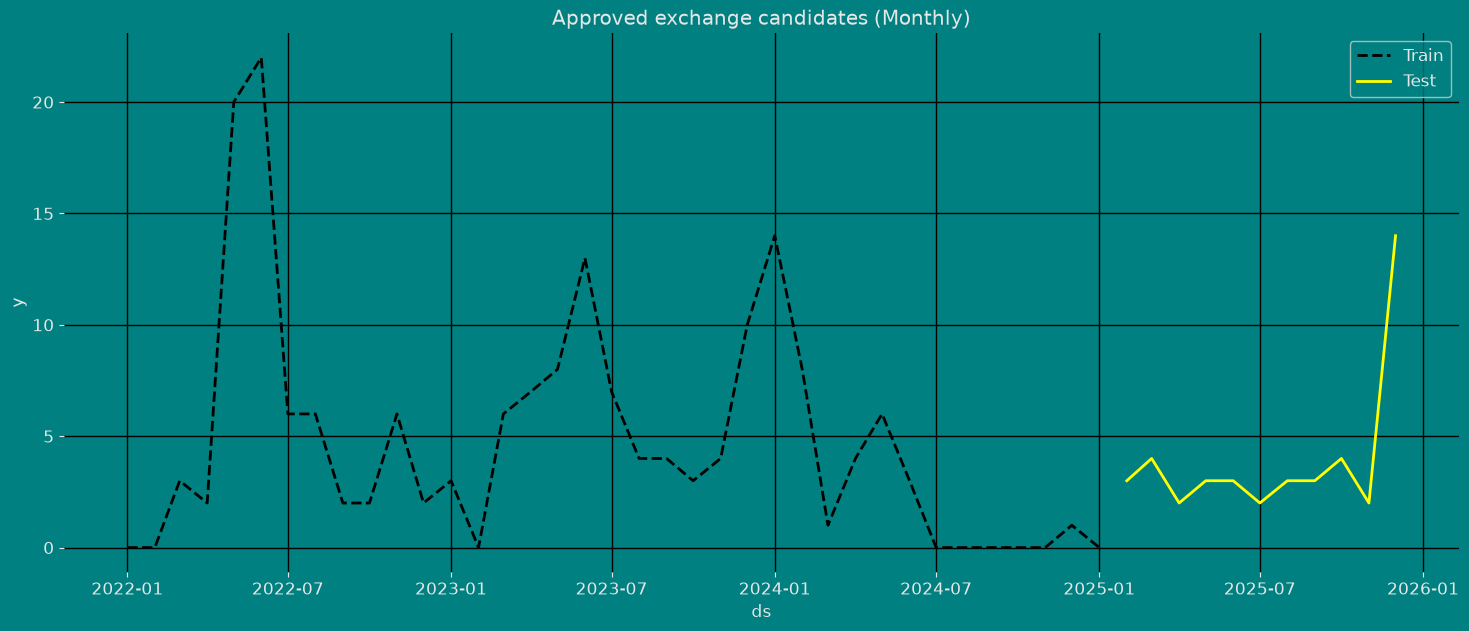

In [4]:
import seaborn as sns
sns.lineplot(train,x="ds", y="y", label="Train", linestyle="--",linewidth=2)
sns.lineplot(test, x="ds", y="y", label="Test", linewidth=2, color="yellow")
plt.title("Approved exchange candidates (Monthly)");
plt.show()

In [5]:
from statsforecast import StatsForecast
from statsforecast.models import HoltWinters, AutoETS

/home/nathan/anaconda3/envs/aiesec-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
season_length = 12
horizon = len(test)

#I'll only use additive model for my case
models = [HoltWinters(season_length= season_length, error_type= "A", alias = "HoltWinters_Additive"),
          AutoETS(season_length= season_length, model= "AAA", alias = "AutoETS_Additive"),]

In [7]:
sf = StatsForecast(models= models, freq= 'MS', n_jobs= 1)

In [8]:
pred = sf.forecast(df= train, h= 12, fitted= True)
pred

,unique_id,ds,HoltWinters_Additive,AutoETS_Additive
0,1,2025-02-01,0.793271,0.793271
1,1,2025-03-01,0.224926,0.224926
2,1,2025-04-01,1.181018,1.181018
3,1,2025-05-01,8.275345,8.275345
4,1,2025-06-01,9.405657,9.405657
5,1,2025-07-01,1.304505,1.304505
6,1,2025-08-01,0.060654,0.060654
7,1,2025-09-01,-1.032695,-1.032695
8,1,2025-10-01,-1.573536,-1.573536
9,1,2025-11-01,-0.178924,-0.178924


In [9]:
#Evaluate models
from functools import partial

import utilsforecast.losses as ufl
from utilsforecast.evaluation import evaluate

In [10]:
evaluate(
    test.merge(pred),
    metrics = [ufl.mae, partial(ufl.mase, seasonality= season_length), ufl.rmse],
    train_df= train
)

,unique_id,metric,HoltWinters_Additive,AutoETS_Additive
0,1,mae,4.214382,4.214382
1,1,mase,0.798178,0.798178
2,1,rmse,5.265787,5.265787


## Final predictinve model
Since both models displayed similar metrics, let me use Holtwinters and train it on the full dataset

In [11]:
full_data = pd.concat(
    [train, test],
    ignore_index=True
).sort_values(["unique_id", "ds"]).reset_index(drop=True)

full_data.head()

,ds,y,unique_id
0,2022-01-01,0,1
1,2022-02-01,0,1
2,2022-03-01,3,1
3,2022-04-01,2,1
4,2022-05-01,20,1


In [12]:
final_model = StatsForecast(
    models= [HoltWinters(season_length= 12, error_type= "A", alias= "HoltWinters_Additive")],
    freq= "MS",
    n_jobs= 1
)

In [14]:
final_model.fit(full_data)
pred_2026 = final_model.predict(h =12)

#I'll assume negative numbers are 0
pred_2026["HoltWinters_Additive"] = (pred_2026["HoltWinters_Additive"].clip(lower= 0))
pred_2026

,unique_id,ds,HoltWinters_Additive
0,1,2026-01-01,1.543864
1,1,2026-02-01,2.448890
2,1,2026-03-01,3.407131
3,1,2026-04-01,1.254703
4,1,2026-05-01,6.673920
5,1,2026-06-01,7.769432
6,1,2026-07-01,1.656877
7,1,2026-08-01,0.573626
8,1,2026-09-01,0.000000
9,1,2026-10-01,0.000000


In [16]:
pred_2026.to_csv("pred_2026.csv", index= False)

In [17]:
import joblib
joblib.dump(final_model, 'model.pkl')

['model.pkl']